## 1. Conceptual Framework & Mathematical Intuition
### 1.1 What is an Elastic Network Model (ENM)?
In structural biology, protein dynamics can be framed around the Harmonic Approximation (like a spring!) near a equilibrium native structure. The Anisotropic Network Model (ANM) treats a protein as a network of point masses (typically $C_\alpha$ atoms) connected by uniform harmonic springs whenever two nodes fall within a spatial interaction cutoff distance $R_c$ (typically $13.0\text{ \AA} - 15.0\text{ \AA}$). Unlike the Gaussian Network Model (GNM), which models isotropic (directionless) scalar fluctuations, ANM captures anisotropic (directional) 3D displacement vectors ($\Delta x, \Delta y, \Delta z$). In other words, while GNM only models how much a residue moves, ANM models both how much and in which 3D direction it moves.
### 1.2 The Potential Energy & The Hessian Matrix
The potential energy $V$ of the spring network as a function of atomic displacement coordinates $\mathbf{\Delta R} \in \mathbb{R}^{3N}$ is given by a second-order Taylor expansion around the energy minimum:$$V = \frac{1}{2} \mathbf{\Delta R}^T \mathbf{H} \mathbf{\Delta R}$$Where $\mathbf{H}$ is the $3N \times 3N$ Hessian matrix, representing the second derivatives of the potential energy with respect to spatial coordinates:$$\mathbf{H} = \begin{bmatrix} \mathbf{H}_{1,1} & \mathbf{H}_{1,2} & \cdots & \mathbf{H}_{1,N} \\ \mathbf{H}_{2,1} & \mathbf{H}_{2,2} & \cdots & \mathbf{H}_{2,N} \\ \vdots & \vdots & \ddots & \vdots \\ \mathbf{H}_{N,1} & \mathbf{H}_{N,2} & \cdots & \mathbf{H}_{N,N} \end{bmatrix}$$Each block $\mathbf{H}_{ij}$ is a $3 \times 3$ sub-matrix defining the spatial directional coupling between node $i$ and node $j$:Off-Diagonal $3 \times 3$ Blocks ($i \neq j$):$$\mathbf{H}_{ij} = -\frac{\gamma}{R_{ij}^2} \begin{bmatrix}   (x_j - x_i)^2 & (x_j - x_i)(y_j - y_i) & (x_j - x_i)(z_j - z_i) \\   (y_j - y_i)(x_j - x_i) & (y_j - y_i)^2 & (y_j - y_i)(z_j - z_i) \\   (z_j - z_i)(x_j - x_i) & (z_j - z_i)(y_j - y_i) & (z_j - z_i)^2   \end{bmatrix} = -\frac{\gamma}{R_{ij}^2} (\mathbf{r}_{ij} \otimes \mathbf{r}_{ij})$$Diagonal $3 \times 3$ Blocks ($i = j$):$$\mathbf{H}_{ii} = -\sum_{j \neq i} \mathbf{H}_{ij}$$
### 1.3 Normal Modes & The Zero-Frequency Modes
Diagonalizing $\mathbf{H}$ via symmetric eigen-decomposition produces $3N$ orthogonal eigenvectors $\mathbf{v}_k$ and non-negative eigenvalues $\lambda_k$:$$\mathbf{H} \mathbf{v}_k = \lambda_k \mathbf{v}_k$$
- Eigenvalue $\lambda_k$: Represents the stiffness (square of frequency $\omega_k^2$) of mode $k$.
- Eigenvector $\mathbf{v}_k$: Describes the collective direction and displacement profile of all nodes along mode $k$.
#### Why are the first 6 eigenvalues zero?
In 3D space, any unconstrained system has **6 rigid-body degrees of freedom**:
- 3 Translational DOFs along $X, Y, Z$
- 3 Rotational DOFs around $X, Y, Z$.  

Because rigid translations and rotations do not stretch or compress any inter-node springs, $V = 0$ for these motions. Thus, modes $k \in \{0, 1, 2, 3, 4, 5\}$ have $\lambda_k \approx 0$. Internal elastic vibrations start at **Mode index 6** (the lowest non-zero eigenvalue, corresponding to the global "slowest" harmonic motion).  
### 1.4 Mean-Square Fluctuations ($\langle \Delta r_i^2 \rangle$)
The thermal fluctuation of residue $i$ is calculated by summing the inverse-eigenvalue-weighted contributions of the non-zero modes:$$\langle \Delta r_i^2 \rangle = k_B T \sum_{k=6}^{3N-1} \frac{1}{\lambda_k} \left( v_{k, 3i}^2 + v_{k, 3i+1}^2 + v_{k, 3i+2}^2 \right)$$
**Inverse Stiffness Weighting ($1/\lambda_k$)**:  
- Slow modes (small $\lambda_k$) dominate large-scale, low-frequency global flexibility. 
- Fast modes (large $\lambda_k$) represent high-frequency, local vibration.

### Side Notes: Where does $3N \times 3N$ Matrix Come From? The Hessian Matrix: Physics & Mathematical Derivation
#### 1. Why Do We Take the Second Derivative?  
To understand why the second derivative is the cornerstone of ANM, consider a Taylor series expansion of the potential energy function $V(\mathbf{R})$ of a protein near its native equilibrium structure $\mathbf{R}_0$:$$V(\mathbf{R}) = V(\mathbf{R}_0) + \sum_{i} \left. \frac{\partial V}{\partial R_i} \right\vert{}_{\mathbf{R}_0} (R_i - R_{0,i}) + \frac{1}{2} \sum_{i, j} \left. \frac{\partial^2 V}{\partial R_i \partial R_j} \right\vert{}_{\mathbf{R}_0} (R_i - R_{0,i})(R_j - R_{0,j}) + \mathcal{O}(\Delta R^3)$$  

Let's examine what happens to each term at equilibrium:
- Zeroth-Order Term ($V(\mathbf{R}_0)$): 
    - The constant base potential energy. We can set $V(\mathbf{R}_0) = 0$ as our reference ground state.
- First-Order Term ($\left. \frac{\partial V}{\partial R_i} \right\vert{}_{\mathbf{R}_0}$): 
    - This derivative represents the net force acting on atom $i$. Because the protein's native structure $\mathbf{R}_0$ sits at a local potential energy minimum (equilibrium), the net forces are zero:$$\nabla V(\mathbf{R}_0) = \mathbf{0}$$Therefore, the linear first-derivative term vanishes entirely.
- Second-Order Term ($\left. \frac{\partial^2 V}{\partial R_i \partial R_j} \right\vert{}_{\mathbf{R}_0}$): 
    - This is the lowest non-zero term that describes how energy changes when the structure is perturbed away from equilibrium. 
    By Hooke's Law ($F = -k x$), force is the first derivative of potential energy, which means the spring constant $k$ (stiffness) is the second derivative of potential energy:$$k = \frac{\partial^2 V}{\partial x^2}$$ 
Taking the second derivative converts the complex, non-linear energy landscape of a protein into **a quadratic harmonic oscillator approximation**. The $3N \times 3N$ matrix of these second partial derivatives is **the Hessian Matrix ($\mathbf{H}$)**.
#### 2. How the $3N \times 3N$ Hessian Matrix is Constructed
In ANM, the total potential energy $V$ of the spring network connects all node pairs $(i, j)$ separated by equilibrium distance $R_{ij}^{(0)}$ within a cutoff $R_c$:$$V = \frac{\gamma}{2} \sum_{i < j} \Theta(R_c - R_{ij}^{(0)}) \left( R_{ij} - R_{ij}^{(0)} \right)^2$$Where $\Theta(\cdot)$ is the Heaviside step function, $\gamma$ is the uniform spring constant, and $R_{ij} = \Vert{}\mathbf{R}_j - \mathbf{R}_i\Vert{}_2$ is the instantaneous distance.To construct the $3N \times 3N$ Hessian $\mathbf{H}$, we calculate the second derivatives with respect to the 3D Cartesian coordinates $(x_i, y_i, z_i)$ of node $i$ and $(x_j, y_j, z_j)$ of node $j$.  
##### A. Off-Diagonal $3 \times 3$ Sub-Blocks ($\mathbf{H}_{ij}$ for $i \neq j$)
The derivative of $V$ with respect to the coordinates of two distinct nodes $i$ and $j$ gives the inter-node directional coupling:$$\mathbf{H}_{ij} = \begin{bmatrix} \frac{\partial^2 V}{\partial x_i \partial x_j} & \frac{\partial^2 V}{\partial x_i \partial y_j} & \frac{\partial^2 V}{\partial x_i \partial z_j} \\ \frac{\partial^2 V}{\partial y_i \partial x_j} & \frac{\partial^2 V}{\partial y_i \partial y_j} & \frac{\partial^2 V}{\partial y_i \partial z_j} \\ \frac{\partial^2 V}{\partial z_i \partial x_j} & \frac{\partial^2 V}{\partial z_i \partial y_j} & \frac{\partial^2 V}{\partial z_i \partial z_j} \end{bmatrix}$$Evaluating these second partial derivatives for a harmonic potential yields:$$\frac{\partial^2 V}{\partial x_i \partial x_j} = -\frac{\gamma}{(R_{ij}^{(0)})^2} (x_j - x_i)(x_j - x_i)$$In vector outer product notation, if $\mathbf{r}_{ij} = \mathbf{R}_j - \mathbf{R}_i = \begin{bmatrix} x_j - x_i & y_j - y_i & z_j - z_i \end{bmatrix}^T$:$$\mathbf{H}_{ij} = -\frac{\gamma}{(R_{ij}^{(0)})^2} (\mathbf{r}_{ij} \otimes \mathbf{r}_{ij}) = -\frac{\gamma}{(R_{ij}^{(0)})^2} \mathbf{r}_{ij} \mathbf{r}_{ij}^T$$Physical Meaning: $\mathbf{H}_{ij}$ projects the scalar spring constant $\gamma$ onto the 3D orientation vector connecting residue $i$ and residue $j$. If two residues lie strictly along the X-axis, compressing them only generates restoring forces along X, making the off-diagonal $Y$ and $Z$ terms zero.
##### B. Diagonal $3 \times 3$ Sub-Blocks ($\mathbf{H}_{ii}$)
By Newton's Third Law (action-reaction conservation), the total forces acting on a closed system must sum to zero under translation. Therefore, the diagonal $3 \times 3$ block $\mathbf{H}_{ii}$ (representing a node's self-restoring force) is simply the negative sum of all off-diagonal blocks connected to node $i$:$$\mathbf{H}_{ii} = -\sum_{j \neq i} \mathbf{H}_{ij}$$This mathematical property guarantees that unconstrained rigid-body translations yield zero net restoring force, ensuring the first 6 eigenvalues of the full $3N \times 3N$ matrix equal exactly zero.

In [1]:
# Setup & Imports
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

# Optional 3D plotting setup
from mpl_toolkits.mplot3d import Axes3D

In [2]:
# Step 2.1: Define a 5-node toy C-alpha backbone chain in 3D
coords = np.array([
    [ 0.0,  0.0, 0.0],
    [ 3.8,  0.0, 0.0],
    [ 6.5,  2.8, 0.0],
    [ 9.0,  5.0, 1.5],
    [12.0,  6.0, 4.0]
])

N = len(coords)
cutoff = 12.0  # Angstroms
gamma = 1.0    # Spring constant

print(f"System initialized with N = {N} residues.")

System initialized with N = 5 residues.


In [17]:
# Step 2.2: Compute pairwise displacement and distance tensors
diffs = coords[:, None, :] - coords[None, :, :]  # Shape: (N, N, 3)
dists = np.linalg.norm(diffs, axis=-1)           # Shape: (N, N)


In [18]:
# Step 2.3: Assemble the 3N x 3N Hessian
H = np.zeros((3 * N, 3 * N))

for i in range(N):
    for j in range(N):
        if i != j and dists[i, j] <= cutoff:
            r_ij = diffs[i, j]
            d_ij = dists[i, j]
            
            # Outer product scaling
            K_ij = -(gamma / (d_ij**2)) * np.outer(r_ij, r_ij)
            
            # Off-diagonal assignment
            H[3*i:3*i+3, 3*j:3*j+3] = K_ij
            
            # Accumulate on diagonal
            H[3*i:3*i+3, 3*i:3*i+3] -= K_ij

print("Hessian Assembly Complete.")
print("Hessian Shape:", H.shape)

Hessian Assembly Complete.
Hessian Shape: (15, 15)


In [26]:
# Step 2.4: Diagonalize Hessian using scipy.linalg.eigh (for symmetric matrices)
eigenvalues, eigenvectors = la.eigh(H)

print("\n--- Eigenvalue Spectrum ---")
for idx, evalue in enumerate(eigenvalues):
    label = "Rigid-Body Zero Mode" if idx < 6 else f"Internal Mode {idx - 6}"
    print(f"Mode {idx:2d} | Eigenvalue: {evalue:12.6f} | ({label})")


--- Eigenvalue Spectrum ---
Mode  0 | Eigenvalue:    -0.000000 | (Rigid-Body Zero Mode)
Mode  1 | Eigenvalue:     0.000000 | (Rigid-Body Zero Mode)
Mode  2 | Eigenvalue:     0.000000 | (Rigid-Body Zero Mode)
Mode  3 | Eigenvalue:     0.000000 | (Rigid-Body Zero Mode)
Mode  4 | Eigenvalue:     0.000000 | (Rigid-Body Zero Mode)
Mode  5 | Eigenvalue:     0.000000 | (Rigid-Body Zero Mode)
Mode  6 | Eigenvalue:     0.001567 | (Internal Mode 0)
Mode  7 | Eigenvalue:     0.102430 | (Internal Mode 1)
Mode  8 | Eigenvalue:     0.200669 | (Internal Mode 2)
Mode  9 | Eigenvalue:     0.240648 | (Internal Mode 3)
Mode 10 | Eigenvalue:     0.425843 | (Internal Mode 4)
Mode 11 | Eigenvalue:     3.050522 | (Internal Mode 5)
Mode 12 | Eigenvalue:     4.516046 | (Internal Mode 6)
Mode 13 | Eigenvalue:     4.703014 | (Internal Mode 7)
Mode 14 | Eigenvalue:     4.759261 | (Internal Mode 8)


In [28]:
eigenvalues

array([-4.12927024e-16,  8.70250105e-18,  1.42716540e-17,  8.39583033e-17,
        9.43076395e-17,  2.29059530e-16,  1.56690317e-03,  1.02429772e-01,
        2.00668868e-01,  2.40648237e-01,  4.25842751e-01,  3.05052188e+00,
        4.51604647e+00,  4.70301373e+00,  4.75926139e+00])

In [32]:
eigenvectors.shape

(15, 15)

In [27]:
# Step 2.5: Compute Mean-Square Fluctuations (MSF) for Node Feature Channel [25]
slow_evals = eigenvalues[6:]
slow_evecs = eigenvectors[:, 6:]

msf = np.zeros(N)
for i in range(N):
    # Extract 3D eigenvector components for node i
    v_i = slow_evecs[3*i : 3*i+3, :]  # Shape: (3, num_modes)
    
    # Calculate sum of squared displacements weighted by inverse eigenvalue
    squared_displacements = np.sum(v_i**2, axis=0)  # (x^2 + y^2 + z^2) per mode
    msf[i] = np.sum(squared_displacements / slow_evals)

# Normalize for node feature standard range
msf_normalized = (msf - np.min(msf)) / (np.max(msf) - np.min(msf) + 1e-8)

print("\n--- Computed Node Feature Channel [25] ---")
for i, (val, norm_val) in enumerate(zip(msf, msf_normalized)):
    print(f"Residue {i}: Raw MSF = {val:.4f} | Normalized = {norm_val:.4f}")


--- Computed Node Feature Channel [25] ---
Residue 0: Raw MSF = 167.6438 | Normalized = 0.8331
Residue 1: Raw MSF = 88.6829 | Normalized = 0.3464
Residue 2: Raw MSF = 32.4753 | Normalized = 0.0000
Residue 3: Raw MSF = 176.8996 | Normalized = 0.8902
Residue 4: Raw MSF = 194.7218 | Normalized = 1.0000


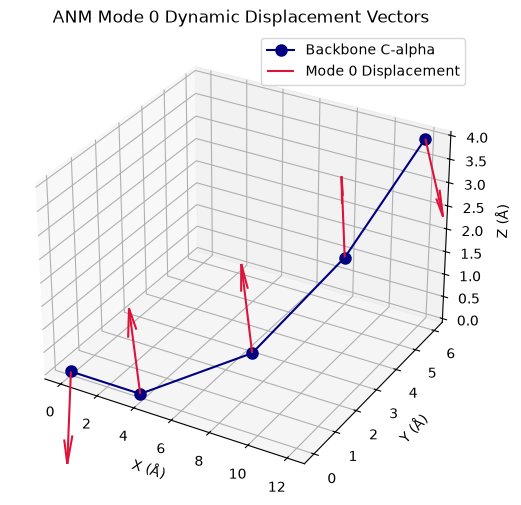

In [33]:
# Step 3.1: Plot Mode 6 (Slowest Functional Motion) Displacement Vectors
mode_idx = 6  # First internal mode
mode_evec = eigenvectors[:, mode_idx]

# Reshape eigenvector into (N, 3) directional vectors
mode_vectors = mode_evec.reshape(N, 3)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot backbone C-alpha trace
ax.plot(coords[:, 0], coords[:, 1], coords[:, 2], 'o-', color='navy', label='Backbone C-alpha', markersize=8)

# Overlay mode displacement vectors using quiver
ax.quiver(
    coords[:, 0], coords[:, 1], coords[:, 2],
    mode_vectors[:, 0], mode_vectors[:, 1], mode_vectors[:, 2],
    color='crimson', length=2.0, normalize=True, label=f'Mode {mode_idx - 6} Displacement'
)

ax.set_title(f"ANM Mode {mode_idx - 6} Dynamic Displacement Vectors")
ax.set_xlabel("X (Å)")
ax.set_ylabel("Y (Å)")
ax.set_zlabel("Z (Å)")
ax.legend()
plt.show()